# 06 — Backtesting: Trading Strategy

Превращаем прогнозы модели в торговую стратегию и считаем **реальные финансовые метрики**.


In [1]:
!pip install -q pytorch-forecasting==1.1.1 lightning numpy==1.26.4 pandas==2.1.4
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 33.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_float32_matmul_precision('medium')

import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

plt.style.use('seaborn-v0_8-whitegrid')

DRIVE_DATA = '/content/drive/MyDrive/predictamarket/data'
MODEL_DIR = '/content/drive/MyDrive/predictamarket/models'
BT_DIR = '/content/drive/MyDrive/predictamarket/backtesting'
os.makedirs(BT_DIR, exist_ok=True)

In [ ]:
CHECKPOINT_NAME = "tft-epoch=05-val_loss=9.3008.ckpt" 
import re as _re
_ckpts_avail = sorted([f for f in os.listdir(MODEL_DIR) if f.endswith('.ckpt')])
if CHECKPOINT_NAME is None:
    CHECKPOINT_NAME = _ckpts_avail[-1]
assert CHECKPOINT_NAME in _ckpts_avail, f'{CHECKPOINT_NAME} not among {_ckpts_avail}'

_m = _re.search(r'epoch=?(\d+)', CHECKPOINT_NAME)
RUN_TAG = f'epoch{int(_m.group(1)):02d}' if _m else CHECKPOINT_NAME.replace('.ckpt', '')

try: BT_DIR_BASE
except NameError: BT_DIR_BASE = BT_DIR
BT_DIR = os.path.join(BT_DIR_BASE, RUN_TAG)
os.makedirs(BT_DIR, exist_ok=True)

print(f'Available checkpoints ({len(_ckpts_avail)}):')
for c in _ckpts_avail:
    print(f'  {"→" if c == CHECKPOINT_NAME else " "} {c}')
print(f'\nUsing:   {CHECKPOINT_NAME}')
print(f'RUN_TAG: {RUN_TAG}')
print(f'Outputs → {BT_DIR}')


Available checkpoints (7):
    tft-epoch=00-val_loss=8.9736.ckpt
    tft-epoch=01-val_loss=7.3249.ckpt
    tft-epoch=02-val_loss=8.8051.ckpt
    tft-epoch=03-val_loss=8.2107.ckpt
    tft-epoch=04-val_loss=9.2586.ckpt
  → tft-epoch=05-val_loss=9.3008.ckpt
    tft-epoch=06-val_loss=9.4489.ckpt

Using:   tft-epoch=05-val_loss=9.3008.ckpt
RUN_TAG: epoch05
Outputs → /content/drive/MyDrive/predictamarket/backtesting/epoch05


In [ ]:
with open(os.path.join(MODEL_DIR, 'config.json')) as f:
    config = json.load(f)
with open(os.path.join(MODEL_DIR, 'training_dataset_params.pkl'), 'rb') as f:
    dataset_params = pickle.load(f)

import pyarrow.parquet as pq
import gc

known_tickers = list(dataset_params['categorical_encoders']['__group_id__ticker'].classes_.keys())
max_encoder_length = dataset_params.get('max_encoder_length', 60)

train_table = pq.read_table(os.path.join(DRIVE_DATA, 'train.parquet'), filters=[('ticker', 'in', known_tickers)])
train_df = train_table.to_pandas()
del train_table
train_df = train_df.groupby('ticker').tail(max_encoder_length + 30).copy()

test_df = pd.read_parquet(os.path.join(DRIVE_DATA, 'test.parquet'))
test_df = test_df[test_df['ticker'].isin(known_tickers)].copy()
gc.collect()

for col in config['static_categoricals'] + config['time_varying_known_categoricals']:
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)
train_df['time_idx'] = train_df['time_idx'].astype(int)
test_df['time_idx'] = test_df['time_idx'].astype(int)
train_df[config['time_varying_unknown_reals']] = train_df[config['time_varying_unknown_reals']].fillna(0)
test_df[config['time_varying_unknown_reals']] = test_df[config['time_varying_unknown_reals']].fillna(0)

for df in [train_df, test_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['Close'], inplace=True)
    df.drop(df[df['Close'] <= 0].index, inplace=True)

for col in train_df.columns:
    if col not in test_df.columns:
        test_df[col] = 0.0
test_df = test_df[train_df.columns]

test_with_history = pd.concat([train_df, test_df], ignore_index=True)
test_with_history = test_with_history.drop_duplicates(subset=['ticker', 'time_idx']).sort_values(['ticker', 'time_idx']).reset_index(drop=True)

# predict=False → sliding windows across test period (~30k trades instead of 400)
test_start_idx = int(test_df['time_idx'].min())

params = dataset_params.copy()
params['allow_missing_timesteps'] = True
training = TimeSeriesDataSet.from_parameters(params, train_df)
try:
    test_ds = TimeSeriesDataSet.from_dataset(
        training, test_with_history,
        predict=False, stop_randomization=True,
        min_prediction_idx=test_start_idx,
    )
except TypeError:
    test_ds = TimeSeriesDataSet.from_dataset(
        training, test_with_history,
        predict=False, stop_randomization=True,
    )
test_dl = test_ds.to_dataloader(train=False, batch_size=128, num_workers=4)

# Per-window prev_close lookup: each sliding window has its OWN prev_close (close at time_idx - 1)
close_lookup = dict(zip(
    zip(test_with_history['ticker'], test_with_history['time_idx']),
    test_with_history['Close']
))

# Load the checkpoint selected in the config cell above
model = TemporalFusionTransformer.load_from_checkpoint(
    os.path.join(MODEL_DIR, CHECKPOINT_NAME), weights_only=False
)
print(f'Loaded: {CHECKPOINT_NAME}')

raw_output = model.predict(test_dl, mode='raw')
pred_with_idx = model.predict(test_dl, return_x=True, return_index=True)

quantiles = raw_output['prediction'].detach().cpu().numpy()
median = quantiles[:, :, 3]
lower = quantiles[:, :, 1]
upper = quantiles[:, :, 5]
actuals = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()
idx = pred_with_idx.index

# Per-window prev_close array (NOT a single price per ticker)
prev_close_arr = np.array([
    close_lookup.get((t, ti - 1), np.nan)
    for t, ti in zip(idx['ticker'].values, idx['time_idx'].values)
])

print(f'Predictions: {median.shape}  (was (400, 22) with predict=True)')
print(f'Test tickers: {idx["ticker"].nunique()}')
print(f'Windows per ticker (avg): {len(idx) / idx["ticker"].nunique():.1f}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Loaded: tft-epoch=05-val_loss=9.3008.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/pr

Predictions: (9200, 22)  (was (400, 22) with predict=True)
Test tickers: 400
Windows per ticker (avg): 23.0


## Signal Generation

Три стратегии на основе прогнозов модели:
- **Strategy A (Direction):** Покупаем если predicted_return > 0, продаём если < 0
- **Strategy B (Confidence):** Торгуем ТОЛЬКО когда модель "уверена" (CI не пересекает текущую цену)
- **Strategy C (Daily Top-K):** Каждый торговый день покупаем top-K тикеров с лучшим predicted return

In [ ]:
valid = (prev_close_arr > 0) & np.isfinite(prev_close_arr)

pred_return_1d = np.where(valid, (median[:, 0] - prev_close_arr) / prev_close_arr, np.nan)
pred_return_5d = np.where(valid, (median[:, 4] - prev_close_arr) / prev_close_arr, np.nan) if median.shape[1] > 4 else np.zeros(len(idx))
ci_width_1d = np.where(valid, (upper[:, 0] - lower[:, 0]) / prev_close_arr, np.nan)

confident_long = (lower[:, 0] > prev_close_arr) & valid
confident_short = (upper[:, 0] < prev_close_arr) & valid

actual_return_1d = np.where(valid, (actuals[:, 0] - prev_close_arr) / prev_close_arr, np.nan)
actual_return_5d = np.where(valid, (actuals[:, 4] - prev_close_arr) / prev_close_arr, np.nan) if actuals.shape[1] > 4 else np.full(len(idx), np.nan)

sig_df = pd.DataFrame({
    'ticker': idx['ticker'].values,
    'time_idx': idx['time_idx'].values,
    'actual_price': prev_close_arr,
    'pred_return_1d': pred_return_1d,
    'pred_return_5d': pred_return_5d,
    'ci_width_1d': ci_width_1d,
    'confident_long': confident_long,
    'confident_short': confident_short,
    'actual_return_1d': actual_return_1d,
    'actual_return_5d': actual_return_5d,
}).dropna(subset=['pred_return_1d', 'actual_return_1d']).reset_index(drop=True)

print(f'Signals: {len(sig_df):,}  (was ~400 with predict=True)')
print(f'Mean predicted 1d return: {sig_df["pred_return_1d"].mean()*100:.3f}%')
print(f'Mean actual 1d return: {sig_df["actual_return_1d"].mean()*100:.3f}%')
print(f'Confident long signals: {sig_df["confident_long"].sum():,}')
print(f'Confident short signals: {sig_df["confident_short"].sum():,}')
print(f'Unique trading days (time_idx): {sig_df["time_idx"].nunique()}')

Signals: 9,200  (was ~400 with predict=True)
Mean predicted 1d return: -3.558%
Mean actual 1d return: 0.109%
Confident long signals: 57
Confident short signals: 1,368
Unique trading days (time_idx): 23


## Strategy backtests

,Strategy,Mean Return,Median Return,Win Rate,Std,Sharpe (annualized),Trades
0,A: Direction (Long UP),0.244%,0.229%,55.3%,4.43%,0.87,2210
1,B: Confident Long,0.522%,0.509%,57.9%,2.75%,3.02,57
2,B: Confident Short,-0.165%,-0.179%,46.4%,3.15%,-0.83,1368
3,C: Daily Top-20 (Long),0.731%,0.181%,53.5%,8.52%,1.36,460
4,C: Daily Bottom-20 (Short),-0.122%,-0.053%,47.6%,5.01%,-0.39,460
5,Buy & Hold (all signals),0.109%,0.184%,54.4%,3.45%,0.50,9200


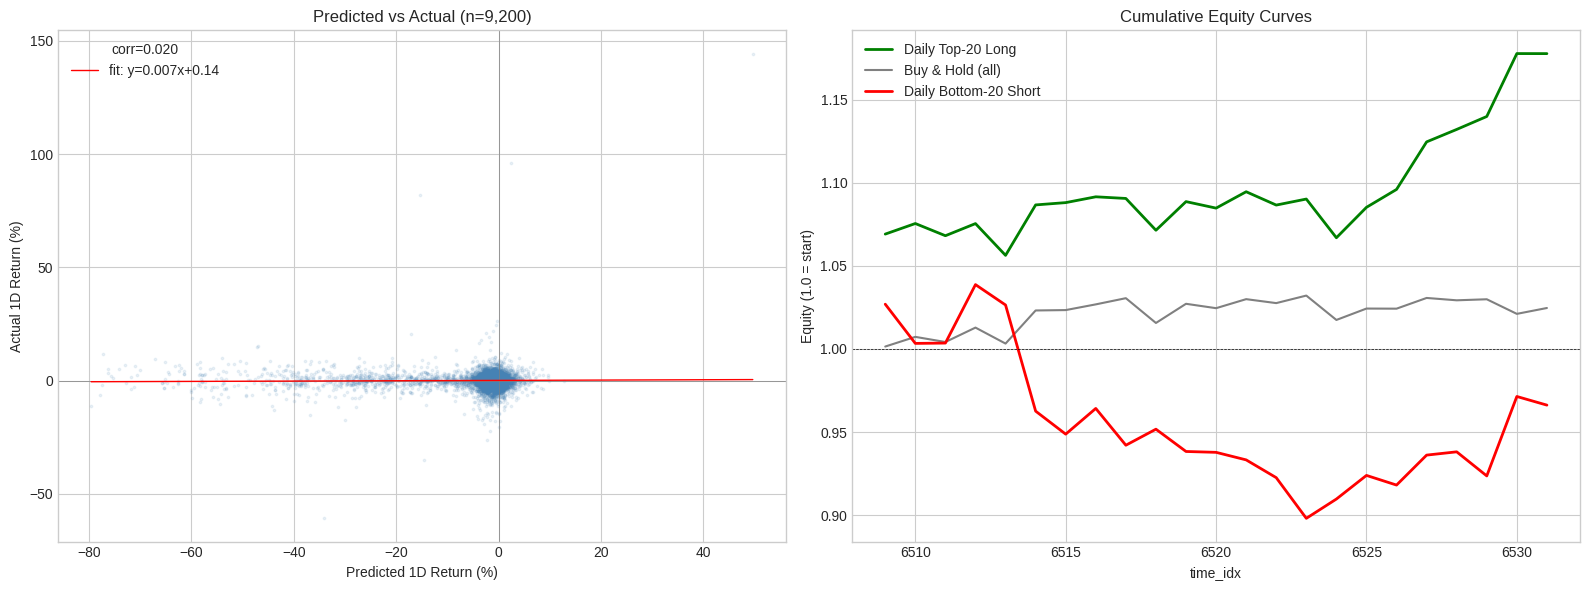


=== Backtesting Summary ===
Test period: 23 trading days
Total signals: 9,200
Unique tickers: 400

Cumulative returns:
  Daily Top-20:        +17.77%
  Buy & Hold:          +2.47%
  Daily Bottom-20 Short: -3.38%

Results: /content/drive/MyDrive/predictamarket/backtesting/epoch05


In [ ]:
def compute_strategy_metrics(returns, name='Strategy'):
    """Compute metrics from returns."""
    if len(returns) == 0: return {'Strategy': name}
    returns = returns.dropna() if hasattr(returns, 'dropna') else returns[~np.isnan(returns)]
    if len(returns) == 0: return {'Strategy': name}
    return {
        'Strategy': name,
        'Mean Return': f'{returns.mean()*100:.3f}%',
        'Median Return': f'{returns.median()*100:.3f}%',
        'Win Rate': f'{(returns > 0).mean()*100:.1f}%',
        'Std': f'{returns.std()*100:.2f}%',
        'Sharpe (annualized)': f'{(returns.mean()/returns.std()*np.sqrt(252)):.2f}' if returns.std() > 0 else '-',
        'Trades': len(returns),
    }


strat_A = sig_df[sig_df['pred_return_1d'] > 0]
metrics_A = compute_strategy_metrics(strat_A['actual_return_1d'], 'A: Direction (Long UP)')

strat_B_long = sig_df[sig_df['confident_long']]
strat_B_short = sig_df[sig_df['confident_short']]
metrics_B_long = compute_strategy_metrics(strat_B_long['actual_return_1d'], 'B: Confident Long')
metrics_B_short = compute_strategy_metrics(-strat_B_short['actual_return_1d'], 'B: Confident Short')

K = 20
daily_top = sig_df.groupby('time_idx', group_keys=False).apply(lambda g: g.nlargest(K, 'pred_return_1d'))
daily_bot = sig_df.groupby('time_idx', group_keys=False).apply(lambda g: g.nsmallest(K, 'pred_return_1d'))

metrics_C = compute_strategy_metrics(daily_top['actual_return_1d'], f'C: Daily Top-{K} (Long)')
metrics_C_short = compute_strategy_metrics(-daily_bot['actual_return_1d'], f'C: Daily Bottom-{K} (Short)')

metrics_BH = compute_strategy_metrics(sig_df['actual_return_1d'], 'Buy & Hold (all signals)')

summary = pd.DataFrame([metrics_A, metrics_B_long, metrics_B_short, metrics_C, metrics_C_short, metrics_BH])
display(summary)
summary.to_csv(os.path.join(BT_DIR, 'strategy_comparison.csv'), index=False)

# Per-day Top-K cumulative equity curve
daily_top_ret = daily_top.groupby('time_idx')['actual_return_1d'].mean()
daily_all_ret = sig_df.groupby('time_idx')['actual_return_1d'].mean()
daily_bot_ret = daily_bot.groupby('time_idx')['actual_return_1d'].mean()

equity_top = (1 + daily_top_ret).cumprod()
equity_bot_short = (1 - daily_bot_ret).cumprod()  # short
equity_bh = (1 + daily_all_ret).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(sig_df['pred_return_1d']*100, sig_df['actual_return_1d']*100, alpha=0.1, s=3, color='steelblue')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Predicted 1D Return (%)'); ax.set_ylabel('Actual 1D Return (%)')
ax.set_title(f'Predicted vs Actual (n={len(sig_df):,})')
# Overlay correlation line
try:
    z = np.polyfit(sig_df['pred_return_1d']*100, sig_df['actual_return_1d']*100, 1)
    xs = np.array([sig_df['pred_return_1d'].min()*100, sig_df['pred_return_1d'].max()*100])
    ax.plot(xs, z[0]*xs + z[1], 'r-', lw=1, label=f'fit: y={z[0]:.3f}x+{z[1]:.2f}')
    corr = sig_df[['pred_return_1d', 'actual_return_1d']].corr().iloc[0, 1]
    ax.legend(title=f'corr={corr:.3f}')
except Exception as e:
    print(f'fit failed: {e}')

ax = axes[1]
equity_top.plot(ax=ax, label=f'Daily Top-{K} Long', color='green', lw=2)
equity_bh.plot(ax=ax, label='Buy & Hold (all)', color='gray', lw=1.5)
equity_bot_short.plot(ax=ax, label=f'Daily Bottom-{K} Short', color='red', lw=2)
ax.set_xlabel('time_idx'); ax.set_ylabel('Equity (1.0 = start)')
ax.set_title('Cumulative Equity Curves')
ax.legend()
ax.axhline(1.0, color='black', lw=0.5, ls='--')

plt.tight_layout()
plt.savefig(os.path.join(BT_DIR, 'strategy_analysis.png'), dpi=150)
plt.show()

# Summary stats
print(f'\n=== Backtesting Summary ===')
print(f'Test period: {sig_df["time_idx"].nunique()} trading days')
print(f'Total signals: {len(sig_df):,}')
print(f'Unique tickers: {sig_df["ticker"].nunique()}')
print(f'\nCumulative returns:')
print(f'  Daily Top-{K}:        {(equity_top.iloc[-1] - 1)*100:+.2f}%')
print(f'  Buy & Hold:          {(equity_bh.iloc[-1] - 1)*100:+.2f}%')
print(f'  Daily Bottom-{K} Short: {(equity_bot_short.iloc[-1] - 1)*100:+.2f}%')
print(f'\nResults: {BT_DIR}')

## Compare All Checkpoints — Trading Metrics

Лучшая эпоха по val_loss ≠ лучшая эпоха по прибыли. Прогоняем все чекпоинты через Top-20, Confident Long, Bottom-20 Short и смотрим кто реально зарабатывает.

In [6]:
import gc

ckpts_all = sorted([f for f in os.listdir(MODEL_DIR) if f.endswith('.ckpt')])
print(f'Found {len(ckpts_all)} checkpoints\n')

bt_compare = []
for ckpt_name in ckpts_all:
    m = TemporalFusionTransformer.load_from_checkpoint(
        os.path.join(MODEL_DIR, ckpt_name), weights_only=False
    )
    raw_out = m.predict(test_dl, mode='raw')
    pidx = m.predict(test_dl, return_x=True, return_index=True)
    q = raw_out['prediction'].detach().cpu().numpy()
    med = q[:, :, 3]; lo = q[:, :, 1]; hi = q[:, :, 5]
    act = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()
    idx_ = pidx.index

    # Per-window prev_close from close_lookup (~30k windows now)
    pc = np.array([close_lookup.get((t, ti - 1), np.nan) for t, ti in zip(idx_['ticker'].values, idx_['time_idx'].values)])
    valid_m = (pc > 0) & np.isfinite(pc)

    pred_r = np.where(valid_m, (med[:, 0] - pc) / pc, np.nan)
    actual_r = np.where(valid_m, (act[:, 0] - pc) / pc, np.nan)
    conf_l = (lo[:, 0] > pc) & valid_m
    conf_s = (hi[:, 0] < pc) & valid_m

    sdf = pd.DataFrame({
        'ticker': idx_['ticker'].values,
        'time_idx': idx_['time_idx'].values,
        'pred_r': pred_r, 'actual_r': actual_r,
        'conf_long': conf_l, 'conf_short': conf_s,
    }).dropna(subset=['pred_r', 'actual_r'])

    # Daily Top-K
    K = 20
    daily_top = sdf.groupby('time_idx', group_keys=False).apply(lambda g: g.nlargest(K, 'pred_r'))
    daily_bot = sdf.groupby('time_idx', group_keys=False).apply(lambda g: g.nsmallest(K, 'pred_r'))
    conf_long_set = sdf[sdf['conf_long']]
    conf_short_set = sdf[sdf['conf_short']]

    def _wr(r): return float((r > 0).mean() * 100) if len(r) else np.nan
    def _mr(r): return float(r.mean() * 100) if len(r) else np.nan
    def _sharpe(r):
        r = r.dropna() if hasattr(r, 'dropna') else r[~np.isnan(r)]
        return float(r.mean()/r.std()*np.sqrt(252)) if len(r) > 1 and r.std() > 0 else np.nan

    # Equity: cumulative product of daily mean returns
    daily_top_ret = daily_top.groupby('time_idx')['actual_r'].mean()
    equity_top = (1 + daily_top_ret).cumprod().iloc[-1] if len(daily_top_ret) else np.nan

    bt_compare.append({
        'checkpoint': ckpt_name,
        'DailyTop20_WR': round(_wr(daily_top['actual_r']), 1),
        'DailyTop20_MeanRet%': round(_mr(daily_top['actual_r']), 3),
        'DailyTop20_Equity': round(equity_top, 3) if np.isfinite(equity_top) else np.nan,
        'DailyTop20_Sharpe': round(_sharpe(daily_top['actual_r']), 2),
        'DailyBot20Short_WR': round(_wr(-daily_bot['actual_r']), 1),
        'DailyBot20Short_MeanRet%': round(_mr(-daily_bot['actual_r']), 3),
        'ConfLong_WR': round(_wr(conf_long_set['actual_r']), 1),
        'ConfLong_MeanRet%': round(_mr(conf_long_set['actual_r']), 3),
        'ConfLong_N': len(conf_long_set),
        'ConfShort_WR': round(_wr(-conf_short_set['actual_r']), 1),
        'ConfShort_N': len(conf_short_set),
        'AllSignals_WR': round(_wr(sdf['actual_r']), 1),
        'N_signals': len(sdf),
    })
    print(f'  {ckpt_name}: Top20 WR={bt_compare[-1]["DailyTop20_WR"]}% MeanRet={bt_compare[-1]["DailyTop20_MeanRet%"]}% Equity={bt_compare[-1]["DailyTop20_Equity"]} ConfLong WR={bt_compare[-1]["ConfLong_WR"]}% (N={bt_compare[-1]["ConfLong_N"]})')

    del m, raw_out, q, pidx
    torch.cuda.empty_cache(); gc.collect()

bt_df = pd.DataFrame(bt_compare).sort_values('DailyTop20_MeanRet%', ascending=False)
print('\n=== Trading Metrics per Checkpoint (sorted by Daily Top-20 mean return) ===')
display(bt_df)

print('\nBest by each trading metric:')
print(f'  Daily Top-20 WR:        {bt_df.loc[bt_df["DailyTop20_WR"].idxmax(), "checkpoint"]}')
print(f'  Daily Top-20 MeanRet:   {bt_df.loc[bt_df["DailyTop20_MeanRet%"].idxmax(), "checkpoint"]}')
print(f'  Daily Top-20 Sharpe:    {bt_df.loc[bt_df["DailyTop20_Sharpe"].idxmax(), "checkpoint"]}')
print(f'  ConfLong MeanRet:       {bt_df.loc[bt_df["ConfLong_MeanRet%"].idxmax(), "checkpoint"]}')

bt_df.to_csv(os.path.join(BT_DIR, 'checkpoint_trading_comparison.csv'), index=False)
print(f'\nSaved to: {BT_DIR}/checkpoint_trading_comparison.csv')


Found 7 checkpoints



INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  tft-epoch=00-val_loss=8.9736.ckpt: Top20 WR=51.5% MeanRet=0.44% Equity=1.101 ConfLong WR=40.0% (N=5)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  tft-epoch=01-val_loss=7.3249.ckpt: Top20 WR=52.2% MeanRet=0.129% Equity=1.028 ConfLong WR=59.8% (N=513)


...

  tft-epoch=05-val_loss=9.3008.ckpt: Top20 WR=53.5% MeanRet=0.731% Equity=1.178 ConfLong WR=57.9% (N=57)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  tft-epoch=06-val_loss=9.4489.ckpt: Top20 WR=53.9% MeanRet=0.149% Equity=1.032 ConfLong WR=59.5% (N=37)

=== Trading Metrics per Checkpoint (sorted by Daily Top-20 mean return) ===


,checkpoint,DailyTop20_WR,DailyTop20_MeanRet%,DailyTop20_Equity,DailyTop20_Sharpe,DailyBot20Short_WR,DailyBot20Short_MeanRet%,ConfLong_WR,ConfLong_MeanRet%,ConfLong_N,ConfShort_WR,ConfShort_N,AllSignals_WR,N_signals
5,tft-epoch=05-val_loss=9.3008.ckpt,53.5,0.731,1.178,1.36,47.6,-0.122,57.9,0.522,57,46.4,1368,54.4,9200
4,tft-epoch=04-val_loss=9.2586.ckpt,49.1,0.588,1.139,0.94,46.5,-0.374,57.9,0.724,57,46.5,2600,54.4,9200
0,tft-epoch=00-val_loss=8.9736.ckpt,51.5,0.440,1.101,0.70,45.9,-0.373,40.0,-1.146,5,47.0,1451,54.4,9200
2,tft-epoch=02-val_loss=8.8051.ckpt,56.3,0.197,1.044,0.97,45.7,-0.875,61.1,0.966,36,46.5,2064,54.4,9200
6,tft-epoch=06-val_loss=9.4489.ckpt,53.9,0.149,1.032,0.76,45.9,-0.280,59.5,0.671,37,47.0,1433,54.4,9200
1,tft-epoch=01-val_loss=7.3249.ckpt,52.2,0.129,1.028,0.71,47.2,-0.370,59.8,0.296,513,45.9,2476,54.4,9200
3,tft-epoch=03-val_loss=8.2107.ckpt,51.1,0.124,1.027,0.65,42.8,-0.877,48.5,0.144,99,46.1,1385,54.4,9200



Best by each trading metric:
  Daily Top-20 WR:        tft-epoch=02-val_loss=8.8051.ckpt
  Daily Top-20 MeanRet:   tft-epoch=05-val_loss=9.3008.ckpt
  Daily Top-20 Sharpe:    tft-epoch=05-val_loss=9.3008.ckpt
  ConfLong MeanRet:       tft-epoch=02-val_loss=8.8051.ckpt

Saved to: /content/drive/MyDrive/predictamarket/backtesting/epoch05/checkpoint_trading_comparison.csv


## Ensemble: Epoch 5 + Epoch 2

Усредняем квантили от двух лучших моделей:
- **Epoch 5** — лучшая в Top-20 ranking (Sharpe 1.36, +17.77%)
- **Epoch 2** — лучшая в Confident Long (Sharpe 5.70, WR 61%)

In [ ]:
import gc

ENSEMBLE_CKPTS = ['tft-epoch=05-val_loss=9.3008.ckpt', 'tft-epoch=02-val_loss=8.8051.ckpt']
WEIGHTS = [0.5, 0.5]

all_quantiles = []
for ckpt_name in ENSEMBLE_CKPTS:
    print(f'Predicting with {ckpt_name}...')
    m = TemporalFusionTransformer.load_from_checkpoint(
        os.path.join(MODEL_DIR, ckpt_name), weights_only=False
    )
    raw_out = m.predict(test_dl, mode='raw')
    q = raw_out['prediction'].detach().cpu().numpy()
    all_quantiles.append(q)
    del m, raw_out
    torch.cuda.empty_cache(); gc.collect()

m = TemporalFusionTransformer.load_from_checkpoint(
    os.path.join(MODEL_DIR, ENSEMBLE_CKPTS[0]), weights_only=False
)
pred_with_idx = m.predict(test_dl, return_x=True, return_index=True)
idx_ens = pred_with_idx.index
actuals_ens = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()
del m, pred_with_idx
torch.cuda.empty_cache(); gc.collect()

q_ens = sum(w * q for w, q in zip(WEIGHTS, all_quantiles))
median_ens = q_ens[:, :, 3]
lower_ens = q_ens[:, :, 1]
upper_ens = q_ens[:, :, 5]

pc_ens = np.array([
    close_lookup.get((t, ti - 1), np.nan)
    for t, ti in zip(idx_ens['ticker'].values, idx_ens['time_idx'].values)
])
valid_ens = (pc_ens > 0) & np.isfinite(pc_ens)

pred_r_ens = np.where(valid_ens, (median_ens[:, 0] - pc_ens) / pc_ens, np.nan)
actual_r_ens = np.where(valid_ens, (actuals_ens[:, 0] - pc_ens) / pc_ens, np.nan)
conf_long_ens = (lower_ens[:, 0] > pc_ens) & valid_ens
conf_short_ens = (upper_ens[:, 0] < pc_ens) & valid_ens

ens_df = pd.DataFrame({
    'ticker': idx_ens['ticker'].values,
    'time_idx': idx_ens['time_idx'].values,
    'pred_r': pred_r_ens,
    'actual_r': actual_r_ens,
    'conf_long': conf_long_ens,
    'conf_short': conf_short_ens,
}).dropna(subset=['pred_r', 'actual_r']).reset_index(drop=True)

K = 20
daily_top_e = ens_df.groupby('time_idx', group_keys=False).apply(lambda g: g.nlargest(K, 'pred_r'))
daily_bot_e = ens_df.groupby('time_idx', group_keys=False).apply(lambda g: g.nsmallest(K, 'pred_r'))
conf_l_e = ens_df[ens_df['conf_long']]
conf_s_e = ens_df[ens_df['conf_short']]

def _strategy(returns, name):
    if len(returns) == 0: return {'Strategy': name}
    returns = returns.dropna() if hasattr(returns, 'dropna') else returns[~np.isnan(returns)]
    if len(returns) == 0: return {'Strategy': name}
    sharpe = float(returns.mean()/returns.std()*np.sqrt(252)) if returns.std() > 0 else 0
    return {
        'Strategy': name,
        'Mean%': round(returns.mean()*100, 3),
        'WR%': round((returns > 0).mean()*100, 1),
        'Sharpe': round(sharpe, 2),
        'N': len(returns),
    }

ens_summary = pd.DataFrame([
    _strategy(ens_df[ens_df['pred_r'] > 0]['actual_r'], 'A: Long UP'),
    _strategy(conf_l_e['actual_r'], 'B: Confident Long'),
    _strategy(-conf_s_e['actual_r'], 'B: Confident Short'),
    _strategy(daily_top_e['actual_r'], f'C: Daily Top-{K}'),
    _strategy(-daily_bot_e['actual_r'], f'C: Daily Bottom-{K} Short'),
    _strategy(ens_df['actual_r'], 'Buy & Hold'),
])

print(f'\n=== ENSEMBLE: {ENSEMBLE_CKPTS[0]} + {ENSEMBLE_CKPTS[1]} (weights {WEIGHTS}) ===')
display(ens_summary)

daily_top_ret_e = daily_top_e.groupby('time_idx')['actual_r'].mean()
equity_top_e = (1 + daily_top_ret_e).cumprod()

print(f'\nEnsemble Daily Top-{K}:')
print(f'  Total return:  {(equity_top_e.iloc[-1] - 1)*100:+.2f}%')
print(f'  N signals:     {len(daily_top_e):,}')
print(f'  N conf long:   {len(conf_l_e)} (WR {(conf_l_e["actual_r"] > 0).mean()*100:.1f}%)')

ens_summary.to_csv(os.path.join(BT_DIR, 'ensemble_strategy_comparison.csv'), index=False)

print('\n=== Quick comparison (Daily Top-20 only) ===')
print(f'Epoch 5 alone:  +17.77% Sharpe 1.36 WR 53.5%')
print(f'Epoch 2 alone:  +4.44%  Sharpe 0.97 WR 56.3%')
print(f'Ensemble:       {(equity_top_e.iloc[-1] - 1)*100:+.2f}% Sharpe {ens_summary[ens_summary["Strategy"]==f"C: Daily Top-{K}"]["Sharpe"].iloc[0]} WR {ens_summary[ens_summary["Strategy"]==f"C: Daily Top-{K}"]["WR%"].iloc[0]}%')


Predicting with tft-epoch=05-val_loss=9.3008.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Predicting with tft-epoch=02-val_loss=8.8051.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


=== ENSEMBLE: tft-epoch=05-val_loss=9.3008.ckpt + tft-epoch=02-val_loss=8.8051.ckpt (weights [0.5, 0.5]) ===


,Strategy,Mean%,WR%,Sharpe,N
0,A: Long UP,0.261,57.4,1.11,2424
1,B: Confident Long,0.664,59.0,3.61,39
2,B: Confident Short,-0.136,46.0,-0.69,1538
3,C: Daily Top-20,0.532,55.0,1.16,460
4,C: Daily Bottom-20 Short,-0.494,46.5,-1.38,460
5,Buy & Hold,0.109,54.4,0.50,9200



Ensemble Daily Top-20:
  Total return:  +12.56%
  N signals:     460
  N conf long:   39 (WR 59.0%)

=== Quick comparison (Daily Top-20 only) ===
Epoch 5 alone:  +17.77% Sharpe 1.36 WR 53.5%
Epoch 2 alone:  +4.44%  Sharpe 0.97 WR 56.3%
Ensemble:       +12.56% Sharpe 1.16 WR 55.0%


## Ensemble 3x: ep2 + ep4 + ep5 — full analysis

Комплексная проверка ансамбля из трёх лучших моделей:
- **ep2** — лучшая в Confident Long (Sharpe 5.70)
- **ep4** — лучшая в MAPE 1d (4.74%)
- **ep5** — лучшая в Top-20 (Sharpe 1.36, +17.77%)

Что считаем:
1. Все метрики (Top-20, ConfLong, MAPE по горизонтам, DirAcc, CI Coverage)
2. 3 варианта весов: equal (1/3), ep5-heavy (0.2/0.3/0.5), ep2-heavy (0.5/0.3/0.2)
3. Корреляции residuals между моделями 
4. MAPE на 1d/3d/5d/10d/22d отдельно — на каких горизонтах ensemble помогает
5. Распределение model disagreement 

In [ ]:
import gc
from itertools import combinations

ENSEMBLE_CKPTS = {
    'ep2': 'tft-epoch=02-val_loss=8.8051.ckpt',
    'ep4': 'tft-epoch=04-val_loss=9.2586.ckpt',
    'ep5': 'tft-epoch=05-val_loss=9.3008.ckpt',
}

print('=== Running inference on 3 models ===')
all_quantiles = {}
for name, ckpt in ENSEMBLE_CKPTS.items():
    print(f'  {name}: {ckpt}...')
    m = TemporalFusionTransformer.load_from_checkpoint(
        os.path.join(MODEL_DIR, ckpt), weights_only=False
    )
    raw_out = m.predict(test_dl, mode='raw')
    q = raw_out['prediction'].detach().cpu().numpy()
    all_quantiles[name] = q
    del m, raw_out
    torch.cuda.empty_cache(); gc.collect()

m = TemporalFusionTransformer.load_from_checkpoint(
    os.path.join(MODEL_DIR, list(ENSEMBLE_CKPTS.values())[0]), weights_only=False
)
pred_with_idx = m.predict(test_dl, return_x=True, return_index=True)
idx_ens = pred_with_idx.index
actuals_ens = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()
del m, pred_with_idx
torch.cuda.empty_cache(); gc.collect()

pc_ens = np.array([
    close_lookup.get((t, ti - 1), np.nan)
    for t, ti in zip(idx_ens['ticker'].values, idx_ens['time_idx'].values)
])

print(f'Predictions shape: {all_quantiles["ep2"].shape}  (samples, horizon, quantiles)')
print(f'Actuals shape: {actuals_ens.shape}')


def compute_metrics(q, name):
    median = q[:, :, 3]
    lower = q[:, :, 1]
    upper = q[:, :, 5]
    valid = (pc_ens > 0) & np.isfinite(pc_ens)

    def mape_at(h):
        a = actuals_ens[:, h]
        p = median[:, h]
        v = (a > 0) & valid
        return np.mean(np.abs((a[v] - p[v]) / a[v])) * 100

    # DirAcc
    a_dir = np.sign(actuals_ens[:, 1] - actuals_ens[:, 0])
    p_dir = np.sign(median[:, 1] - median[:, 0])
    diracc_1d = float(np.mean(a_dir == p_dir))

    correct = []
    for t in range(1, actuals_ens.shape[1]):
        correct.append(np.mean(np.sign(actuals_ens[:, t] - actuals_ens[:, t-1]) ==
                               np.sign(median[:, t] - median[:, t-1])))
    diracc_22d = float(np.mean(correct))

    # CI 80% coverage
    ci80_1d = float(np.mean((actuals_ens[:, 0] >= lower[:, 0]) & (actuals_ens[:, 0] <= upper[:, 0])))

    # Trading
    pred_r = np.where(valid, (median[:, 0] - pc_ens) / pc_ens, np.nan)
    actual_r = np.where(valid, (actuals_ens[:, 0] - pc_ens) / pc_ens, np.nan)
    conf_long = (lower[:, 0] > pc_ens) & valid
    sdf = pd.DataFrame({
        'ticker': idx_ens['ticker'].values,
        'time_idx': idx_ens['time_idx'].values,
        'pred_r': pred_r,
        'actual_r': actual_r,
        'conf_long': conf_long,
    }).dropna(subset=['pred_r', 'actual_r'])

    K = 20
    daily_top = sdf.groupby('time_idx', group_keys=False).apply(lambda g: g.nlargest(K, 'pred_r'))
    daily_top_ret = daily_top.groupby('time_idx')['actual_r'].mean()
    equity_top = float((1 + daily_top_ret).cumprod().iloc[-1]) if len(daily_top_ret) else float('nan')

    top20_r = daily_top['actual_r']
    top20_sharpe = float(top20_r.mean() / top20_r.std() * np.sqrt(252)) if top20_r.std() > 0 else 0.0

    cl = sdf[sdf['conf_long']]
    if len(cl) > 1 and cl['actual_r'].std() > 0:
        cl_sharpe = float(cl['actual_r'].mean() / cl['actual_r'].std() * np.sqrt(252))
        cl_wr = float((cl['actual_r'] > 0).mean() * 100)
    else:
        cl_sharpe = float('nan')
        cl_wr = float('nan')

    return {
        'Model': name,
        'Top-20 %': round((equity_top - 1) * 100, 2) if np.isfinite(equity_top) else np.nan,
        'Top-20 Sh': round(top20_sharpe, 2),
        'ConfLong Sh': round(cl_sharpe, 2),
        'ConfLong N': len(cl),
        'ConfLong WR': round(cl_wr, 1),
        'MAPE 1d': round(mape_at(0), 2),
        'MAPE 22d': round(mape_at(21), 2),
        'DirAcc 1d': round(diracc_1d, 3),
        'DirAcc 22d': round(diracc_22d, 3),
        'CI Cov 80%': round(ci80_1d, 3),
    }


results = []

# Individual
for name in ['ep2', 'ep4', 'ep5']:
    results.append(compute_metrics(all_quantiles[name], name))

# Ensemble variants
WEIGHT_VARIANTS = {
    'ENS equal (1/3,1/3,1/3)': [1/3, 1/3, 1/3],
    'ENS ep5-heavy (0.2,0.3,0.5)': [0.2, 0.3, 0.5],
    'ENS ep2-heavy (0.5,0.3,0.2)': [0.5, 0.3, 0.2],
}

ensemble_quantiles = {}
for vname, w in WEIGHT_VARIANTS.items():
    q_ens = w[0]*all_quantiles['ep2'] + w[1]*all_quantiles['ep4'] + w[2]*all_quantiles['ep5']
    ensemble_quantiles[vname] = q_ens
    results.append(compute_metrics(q_ens, vname))

comparison_df = pd.DataFrame(results)
print('\n=== FULL COMPARISON TABLE ===')
display(comparison_df)
comparison_df.to_csv(os.path.join(BT_DIR, 'ensemble_3_comparison.csv'), index=False)


print('\n=== Residual Correlations (pred_1d_median - actual_1d) ===')
print('Цель: <0.5 = модели разные, ансамбль поможет; >0.9 = одинаковые, не поможет')
residuals = {name: all_quantiles[name][:, 0, 3] - actuals_ens[:, 0] for name in ENSEMBLE_CKPTS}
for a, b in combinations(residuals.keys(), 2):
    corr = np.corrcoef(residuals[a], residuals[b])[0, 1]
    verdict = '❌ too similar' if corr > 0.9 else '⚠️ moderate' if corr > 0.7 else '✅ complementary'
    print(f'  corr({a}, {b}) = {corr:.3f}  {verdict}')


print('\n=== MAPE by Horizon ===')
horizons = [(0, '1d'), (2, '3d'), (4, '5d'), (9, '10d'), (21, '22d')]

hz_rows = []
def mape_h(q, h):
    a = actuals_ens[:, h]
    p = q[:, h, 3]
    v = (a > 0) & (pc_ens > 0) & np.isfinite(pc_ens)
    return round(np.mean(np.abs((a[v] - p[v]) / a[v])) * 100, 2)

for name in ['ep2', 'ep4', 'ep5']:
    row = {'Model': name}
    for h, lbl in horizons:
        row[f'MAPE {lbl}'] = mape_h(all_quantiles[name], h)
    hz_rows.append(row)

for vname, q_ens in ensemble_quantiles.items():
    row = {'Model': vname}
    for h, lbl in horizons:
        row[f'MAPE {lbl}'] = mape_h(q_ens, h)
    hz_rows.append(row)

horizon_df = pd.DataFrame(hz_rows)
display(horizon_df)

# Best ensemble at each horizon vs best individual
print('\nBest model per horizon:')
for h, lbl in horizons:
    col = f'MAPE {lbl}'
    best_ind = horizon_df.iloc[:3][col].min()
    best_ind_model = horizon_df.iloc[:3].loc[horizon_df.iloc[:3][col].idxmin(), 'Model']
    best_ens = horizon_df.iloc[3:][col].min()
    best_ens_model = horizon_df.iloc[3:].loc[horizon_df.iloc[3:][col].idxmin(), 'Model']
    winner = 'ensemble' if best_ens < best_ind else 'individual'
    improvement_pct = (best_ind - best_ens) / best_ind * 100 if best_ind > 0 else 0
    print(f'  {lbl}: best individual = {best_ind:.2f}% ({best_ind_model}), best ensemble = {best_ens:.2f}% ({best_ens_model}), Δ = {improvement_pct:+.1f}%  [{winner}]')


print('\n=== Model Disagreement (Uncertainty Score) ===')
print('std(medians)/|mean(medians)| — high value = модели спорят, low = согласны')
medians_stack = np.stack([all_quantiles['ep2'][:, 0, 3],
                          all_quantiles['ep4'][:, 0, 3],
                          all_quantiles['ep5'][:, 0, 3]], axis=1)
med_std = np.std(medians_stack, axis=1)
med_mean = np.abs(np.mean(medians_stack, axis=1))
disagreement = med_std / (med_mean + 1e-9)

for p in [10, 25, 50, 75, 90]:
    print(f'  p{p}: {np.percentile(disagreement, p):.4f}')

print(f'\n  mean disagreement: {disagreement.mean():.4f}')
print(f'  max disagreement:  {disagreement.max():.4f}')


print('\n=== VERDICT ===')
# Compare best ensemble to best individual by Top-20 Sharpe
best_ind_sharpe = max(r['Top-20 Sh'] for r in results[:3])
best_ens_sharpe = max(r['Top-20 Sh'] for r in results[3:])
best_ind_mape = min(r['MAPE 1d'] for r in results[:3])
best_ens_mape = min(r['MAPE 1d'] for r in results[3:])

mape_improvement = (best_ind_mape - best_ens_mape) / best_ind_mape * 100
sharpe_delta = best_ens_sharpe - best_ind_sharpe

print(f'Best individual Top-20 Sharpe: {best_ind_sharpe}')
print(f'Best ensemble Top-20 Sharpe:   {best_ens_sharpe}')
print(f'Delta: {sharpe_delta:+.2f}')
print()
print(f'Best individual MAPE 1d: {best_ind_mape}%')
print(f'Best ensemble MAPE 1d:   {best_ens_mape}%')
print(f'Improvement: {mape_improvement:+.1f}%')
print()

if mape_improvement >= 5 or sharpe_delta >= 0.2:
    print('✅ ENSEMBLE WORTH IT — significant improvement')
elif mape_improvement >= 3 or sharpe_delta >= 0.1:
    print('⚠️  MARGINAL — worth testing in live but not obvious win')
else:
    print('❌ ENSEMBLE NOT WORTH IT — stick with best individual model')
    print('   Doesn\'t justify 3x inference cost + complexity')


=== Running inference on 3 models ===
  ep2: tft-epoch=02-val_loss=8.8051.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  ep4: tft-epoch=04-val_loss=9.2586.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  ep5: tft-epoch=05-val_loss=9.3008.ckpt...


...

Predictions shape: (9200, 22, 7)  (samples, horizon, quantiles)
Actuals shape: (9200, 22)

=== FULL COMPARISON TABLE ===


,Model,Top-20 %,Top-20 Sh,ConfLong Sh,ConfLong N,ConfLong WR,MAPE 1d,MAPE 22d,DirAcc 1d,DirAcc 22d,CI Cov 80%
0,ep2,4.44,0.97,5.70,36,61.1,5.32,11.99,0.515,0.535,0.689
1,ep4,13.87,0.94,3.67,57,57.9,4.74,14.73,0.474,0.518,0.602
2,ep5,17.77,1.36,3.02,57,57.9,4.86,12.65,0.480,0.512,0.712
3,"ENS equal (1/3,1/3,1/3)",19.19,1.45,8.15,27,63.0,4.78,12.49,0.488,0.527,0.689
4,"ENS ep5-heavy (0.2,0.3,0.5)",19.74,1.49,2.01,35,54.3,4.75,12.63,0.481,0.522,0.692
5,"ENS ep2-heavy (0.5,0.3,0.2)",17.10,1.31,8.04,28,64.3,4.86,12.26,0.498,0.531,0.690



=== Residual Correlations (pred_1d_median - actual_1d) ===
Цель: <0.5 = модели разные, ансамбль поможет; >0.9 = одинаковые, не поможет
  corr(ep2, ep4) = 0.978  ❌ too similar
  corr(ep2, ep5) = 0.989  ❌ too similar
  corr(ep4, ep5) = 0.989  ❌ too similar

=== MAPE by Horizon ===


,Model,MAPE 1d,MAPE 3d,MAPE 5d,MAPE 10d,MAPE 22d
0,ep2,5.32,6.50,7.35,9.08,11.99
1,ep4,4.74,5.90,6.82,9.03,14.73
2,ep5,4.86,6.05,6.99,9.03,12.65
3,"ENS equal (1/3,1/3,1/3)",4.78,5.97,6.88,8.79,12.49
4,"ENS ep5-heavy (0.2,0.3,0.5)",4.75,5.95,6.87,8.82,12.63
5,"ENS ep2-heavy (0.5,0.3,0.2)",4.86,6.05,6.95,8.79,12.26



Best model per horizon:
  1d: best individual = 4.74% (ep4), best ensemble = 4.75% (ENS ep5-heavy (0.2,0.3,0.5)), Δ = -0.2%  [individual]
  3d: best individual = 5.90% (ep4), best ensemble = 5.95% (ENS ep5-heavy (0.2,0.3,0.5)), Δ = -0.8%  [individual]
  5d: best individual = 6.82% (ep4), best ensemble = 6.87% (ENS ep5-heavy (0.2,0.3,0.5)), Δ = -0.7%  [individual]
  10d: best individual = 9.03% (ep4), best ensemble = 8.79% (ENS equal (1/3,1/3,1/3)), Δ = +2.7%  [ensemble]
  22d: best individual = 11.99% (ep2), best ensemble = 12.26% (ENS ep2-heavy (0.5,0.3,0.2)), Δ = -2.3%  [individual]

=== Model Disagreement (Uncertainty Score) ===
std(medians)/|mean(medians)| — high value = модели спорят, low = согласны
  p10: 0.0030
  p25: 0.0050
  p50: 0.0078
  p75: 0.0115
  p90: 0.0159

  mean disagreement: 0.0108
  max disagreement:  0.5837

=== VERDICT ===
Best individual Top-20 Sharpe: 1.36
Best ensemble Top-20 Sharpe:   1.49
Delta: +0.13

Best individual MAPE 1d: 4.74%
Best ensemble MAPE 1d:  

## DirAcc via Majority Vote vs Price-Averaged Sign

In [ ]:
import gc
import numpy as np

ALL_EPOCHS = {
    'ep0': 'tft-epoch=00-val_loss=8.9736.ckpt',
    'ep1': 'tft-epoch=01-val_loss=7.3249.ckpt',
    'ep2': 'tft-epoch=02-val_loss=8.8051.ckpt',
    'ep3': 'tft-epoch=03-val_loss=8.2107.ckpt',
    'ep4': 'tft-epoch=04-val_loss=9.2586.ckpt',
    'ep5': 'tft-epoch=05-val_loss=9.3008.ckpt',
    'ep6': 'tft-epoch=06-val_loss=9.4489.ckpt',
}

# Load any missing into all_quantiles dict (should exist from previous ensemble cell)
try:
    all_quantiles
except NameError:
    all_quantiles = {}
    print('(initializing all_quantiles from scratch)')

missing = [k for k in ALL_EPOCHS if k not in all_quantiles]
if missing:
    print(f'Loading missing checkpoints: {missing}')
    for k in missing:
        print(f'  {k}: {ALL_EPOCHS[k]}...')
        m = TemporalFusionTransformer.load_from_checkpoint(
            os.path.join(MODEL_DIR, ALL_EPOCHS[k]), weights_only=False
        )
        raw_out = m.predict(test_dl, mode='raw')
        all_quantiles[k] = raw_out['prediction'].detach().cpu().numpy()
        del m, raw_out
        torch.cuda.empty_cache(); gc.collect()
else:
    print('All 7 checkpoints already in memory')

# Ensure we have idx + actuals + pc (should be from previous cell)
try:
    _ = pc_ens; _ = actuals_ens; _ = idx_ens
except NameError:
    # Rebuild if needed
    m = TemporalFusionTransformer.load_from_checkpoint(
        os.path.join(MODEL_DIR, ALL_EPOCHS['ep5']), weights_only=False
    )
    pred_with_idx = m.predict(test_dl, return_x=True, return_index=True)
    idx_ens = pred_with_idx.index
    actuals_ens = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()
    pc_ens = np.array([
        close_lookup.get((t, ti - 1), np.nan)
        for t, ti in zip(idx_ens['ticker'].values, idx_ens['time_idx'].values)
    ])
    del m, pred_with_idx
    torch.cuda.empty_cache(); gc.collect()

Q_MEDIAN = 3


# --- DirAcc computation with 3 methods ---
def compute_dir_metrics(models, horizon_step):
    """
    For each sample, compute direction using 3 methods:
    A: average prices across models first, then sign of delta vs baseline
    B: each model votes sign, majority wins
    C: soft vote — average percentage return across models, sign of avg
    """
    # Baseline: prev_close (real price just before prediction window)
    baseline = pc_ens  # (N,)
    # True direction = sign(actual at horizon - prev_close)
    true_sign = np.sign(actuals_ens[:, horizon_step] - baseline)

    # Stack model medians at this horizon: (n_models, N)
    stacked = np.stack([all_quantiles[m][:, horizon_step, Q_MEDIAN] for m in models], axis=0)

    # A: price-averaged sign
    avg_price = stacked.mean(axis=0)
    avg_sign = np.sign(avg_price - baseline)

    # B: majority vote — each model gives sign, sum, take sign
    per_model_signs = np.sign(stacked - baseline[np.newaxis, :])
    vote_sum = per_model_signs.sum(axis=0)
    majority_sign = np.sign(vote_sum)

    # C: soft vote — average % return, sign of avg
    safe_baseline = np.where(baseline != 0, baseline, 1)
    per_model_ret = (stacked - baseline[np.newaxis, :]) / safe_baseline[np.newaxis, :]
    soft_score = per_model_ret.mean(axis=0)
    soft_sign = np.sign(soft_score)

    valid = (baseline > 0) & np.isfinite(baseline)

    return {
        'price_avg': float(np.mean(avg_sign[valid] == true_sign[valid])),
        'majority': float(np.mean(majority_sign[valid] == true_sign[valid])),
        'soft_vote': float(np.mean(soft_sign[valid] == true_sign[valid])),
        'n_samples': int(valid.sum()),
        'ties': int((vote_sum == 0).sum()),  # ties happen when 1 vs 1 (even N) or all zeros
    }


# ---------- Main: ep2+ep4+ep5 (current ensemble) across 5 horizons ----------
print('\n=== DirAcc methods comparison: ep2+ep4+ep5 across horizons ===\n')
print(f'{"Horizon":<10} {"PriceAvg":>10} {"Majority":>10} {"SoftVote":>10} {"Ties":>8} {"N":>8}')
print('-' * 60)

horizon_steps = [('1d', 0), ('3d', 2), ('1w', 4), ('2w', 9), ('22d', 21)]
results_main = []
for h_label, h_step in horizon_steps:
    r = compute_dir_metrics(['ep2', 'ep4', 'ep5'], h_step)
    print(f'{h_label:<10} {r["price_avg"]:>10.3f} {r["majority"]:>10.3f} {r["soft_vote"]:>10.3f} {r["ties"]:>8d} {r["n_samples"]:>8d}')
    results_main.append({'horizon': h_label, **r})


# ---------- Alternative model combinations ----------
combos = [
    ['ep1', 'ep2', 'ep3'],   # top-3 by single-epoch DirAcc
    ['ep1', 'ep2', 'ep5'],   # direction-strong + price-strong mix
    ['ep2', 'ep4', 'ep5'],   # current ensemble
    ['ep0', 'ep1', 'ep2', 'ep3', 'ep4'],  # 5 early+mid epochs (odd N)
    ['ep0', 'ep1', 'ep2', 'ep3', 'ep4', 'ep5', 'ep6'],  # ALL 7 epochs
]

print('\n=== Majority Vote DirAcc across model combinations ===\n')
print(f'{"Combo":<45} {"1d":>8} {"3d":>8} {"1w":>8} {"2w":>8} {"22d":>8} {"Ties1d":>8}')
print('-' * 90)

combo_results = []
for combo in combos:
    row = {'combo': '+'.join(combo)}
    ties_1d = 0
    for h_label, h_step in horizon_steps:
        r = compute_dir_metrics(combo, h_step)
        row[h_label] = r['majority']
        if h_step == 0: ties_1d = r['ties']
    row['ties_1d'] = ties_1d
    combo_results.append(row)
    print(f'{row["combo"]:<45} {row["1d"]:>8.3f} {row["3d"]:>8.3f} {row["1w"]:>8.3f} {row["2w"]:>8.3f} {row["22d"]:>8.3f} {ties_1d:>8d}')


# ---------- Soft vote for best combo ----------
print('\n=== Soft vote across model combinations ===\n')
print(f'{"Combo":<45} {"1d":>8} {"3d":>8} {"1w":>8} {"2w":>8} {"22d":>8}')
print('-' * 82)
for combo in combos:
    row_soft = {'combo': '+'.join(combo)}
    for h_label, h_step in horizon_steps:
        r = compute_dir_metrics(combo, h_step)
        row_soft[h_label] = r['soft_vote']
    print(f'{row_soft["combo"]:<45} {row_soft["1d"]:>8.3f} {row_soft["3d"]:>8.3f} {row_soft["1w"]:>8.3f} {row_soft["2w"]:>8.3f} {row_soft["22d"]:>8.3f}')


# ---------- Single-model baselines ----------
print('\n=== Single-model DirAcc (baseline for comparison) ===\n')
print(f'{"Model":<10} {"1d":>8} {"3d":>8} {"1w":>8} {"2w":>8} {"22d":>8}')
print('-' * 52)
single_results = {}
for m in ['ep0', 'ep1', 'ep2', 'ep3', 'ep4', 'ep5', 'ep6']:
    row = {'model': m}
    for h_label, h_step in horizon_steps:
        r = compute_dir_metrics([m], h_step)
        row[h_label] = r['majority']  # for single model, majority == price_avg
    single_results[m] = row
    print(f'{m:<10} {row["1d"]:>8.3f} {row["3d"]:>8.3f} {row["1w"]:>8.3f} {row["2w"]:>8.3f} {row["22d"]:>8.3f}')


# ---------- VERDICT ----------
print('\n=== VERDICT ===\n')

# Best single model 1d vs best ensemble majority 1d
best_single_1d = max(single_results.values(), key=lambda x: x['1d'])
best_single_22d = max(single_results.values(), key=lambda x: x['22d'])
best_majority_1d = max(combo_results, key=lambda x: x['1d'])
best_majority_22d = max(combo_results, key=lambda x: x['22d'])

delta_1d = best_majority_1d['1d'] - best_single_1d['1d']
delta_22d = best_majority_22d['22d'] - best_single_22d['22d']

print(f'Best single 1d:      {best_single_1d["model"]} = {best_single_1d["1d"]:.3f}')
print(f'Best majority 1d:    {best_majority_1d["combo"]} = {best_majority_1d["1d"]:.3f}')
print(f'Delta 1d:            {delta_1d:+.3f} pp')
print()
print(f'Best single 22d:     {best_single_22d["model"]} = {best_single_22d["22d"]:.3f}')
print(f'Best majority 22d:   {best_majority_22d["combo"]} = {best_majority_22d["22d"]:.3f}')
print(f'Delta 22d:           {delta_22d:+.3f} pp')
print()

# Verdict with threshold
if delta_1d >= 0.03 or delta_22d >= 0.03:
    print('✅ MAJORITY VOTE WORTH IT — >=3pp improvement on at least one horizon')
elif delta_1d >= 0.015 or delta_22d >= 0.015:
    print('⚠️  MARGINAL — 1.5-3pp improvement, test in paper-trading')
else:
    print('❌ NOT WORTH IT — improvement <1.5pp')
    print('   Майоритарное голосование не даёт значимого прироста.')
    print('   Оставить best single model или price-averaged ensemble.')

# Statistical significance check at N=9200, SE ~ 0.52%
se = np.sqrt(0.5 * 0.5 / 9200) * 100
print(f'\nNote: N=9200, SE for proportion = {se:.2f}pp')
print(f'Any delta > {2*se:.2f}pp is statistically significant (2-sigma)')


Loading missing checkpoints: ['ep0', 'ep1', 'ep3', 'ep6']
  ep0: tft-epoch=00-val_loss=8.9736.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  ep1: tft-epoch=01-val_loss=7.3249.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  ep3: tft-epoch=03-val_loss=8.2107.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  ep6: tft-epoch=06-val_loss=9.4489.ckpt...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


=== DirAcc methods comparison: ep2+ep4+ep5 across horizons ===

Horizon      PriceAvg   Majority   SoftVote     Ties        N
------------------------------------------------------------
1d              0.488      0.485      0.488        0     9200
3d              0.497      0.489      0.497        0     9200
1w              0.519      0.511      0.519        0     9200
2w              0.563      0.561      0.563        0     9200
22d             0.680      0.678      0.680        0     9200

=== Majority Vote DirAcc across model combinations ===

Combo                                               1d       3d       1w       2w      22d   Ties1d
------------------------------------------------------------------------------------------
ep1+ep2+ep3                                      0.495    0.506    0.517    0.566    0.671        0
ep1+ep2+ep5                                      0.492    0.497    0.514    0.565    0.673        0
ep2+ep4+ep5                                      0.485